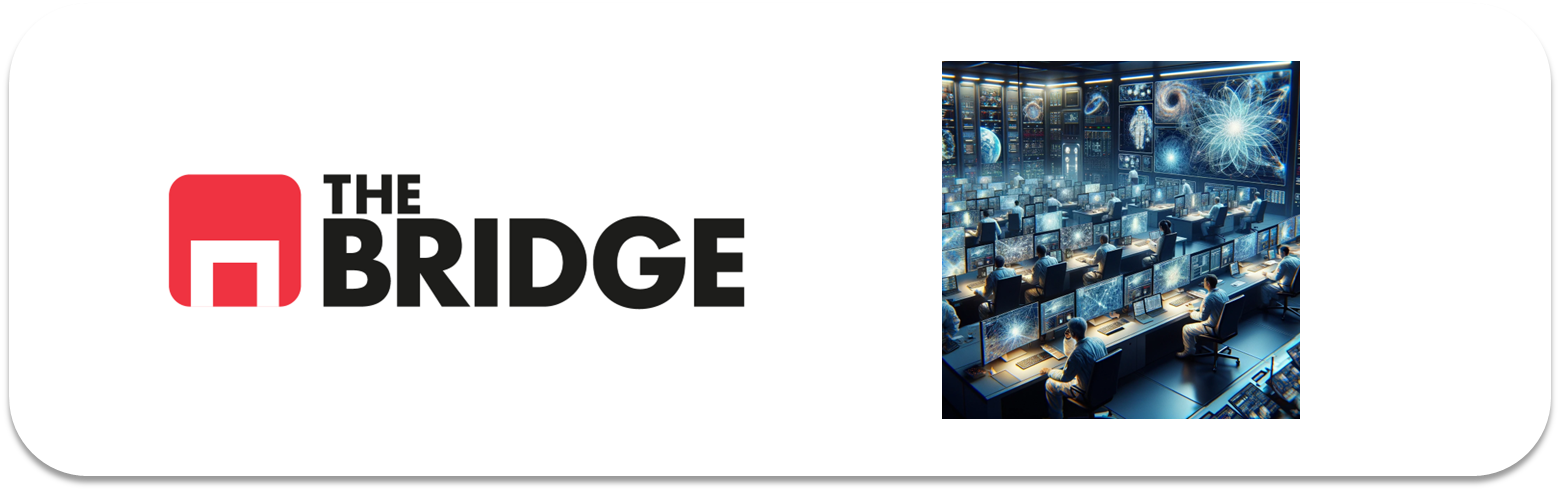

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf



from skimage.io import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models



### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


In [ ]:
# locate train and test datasets
os.listdir("../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data")

['seg_test', 'seg_train']

In [ ]:
# store paths for datasets in variables
train_dir = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_train"
test_dir = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_test"

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2  # 80/20 split
)

In [13]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 11230 images belonging to 6 classes.


In [16]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2804 images belonging to 6 classes.


In [17]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # IMPORTANT for evaluation
)

Found 3000 images belonging to 6 classes.


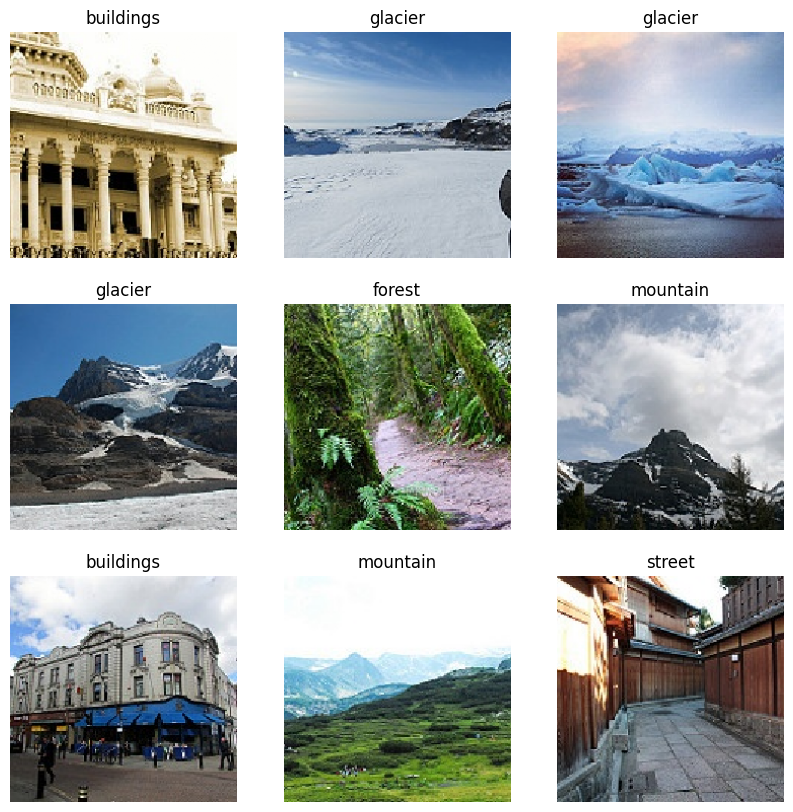

In [ ]:
# create function to show images and confirm images and labels
class_names = list(train_generator.class_indices.keys())

def show_images(generator):
    images, labels = next(generator)
    
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow((images[i] + 1) / 2)  # de-normalize
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
    plt.show()

show_images(train_generator)

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
# choose base model to retrain
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# freeze model
base_model.trainable = False

In [ ]:
# create new head with output for model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)   # hidden layer 1
x = layers.Dense(64, activation='relu')(x)    # hidden layer 2

outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)

In [ ]:
# prepare model
model = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# show model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,430,598 (9.27 MB)

 Trainable params: 172,614 (674.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 164s 453ms/step - accuracy: 0.8875 - loss: 0.3082 - val_accuracy: 0.8927 - val_loss: 0.2902
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.9194 - loss: 0.2127 - val_accuracy: 0.9016 - val_loss: 0.2691
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.9304 - loss: 0.1800 - val_accuracy: 0.9137 - val_loss: 0.2358
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.9454 - loss: 0.1478 - val_accuracy: 0.9098 - val_loss: 0.2587
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.9500 - loss: 0.1275 - val_accuracy: 0.9087 - val_loss: 0.2725
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.9598 - loss: 0.1055 - val_accuracy: 0.9169 - val_loss: 0.2609
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.9664 - loss: 0.0868 - val_accuracy: 0.9073 - val_loss: 0.3094
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.9723 - loss: 

In [ ]:
# evaluate model with test
test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 561ms/step - accuracy: 0.9137 - loss: 0.3410
Test accuracy: 0.9136666655540466


In [ ]:
# generate predictions for classification
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step


In [ ]:
# print classification
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.96      0.86      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.82      0.91      0.86       553
    mountain       0.91      0.80      0.85       525
         sea       0.95      0.96      0.96       510
      street       0.89      0.96      0.92       501

    accuracy                           0.91      3000
   macro avg       0.92      0.91      0.92      3000
weighted avg       0.92      0.91      0.91      3000



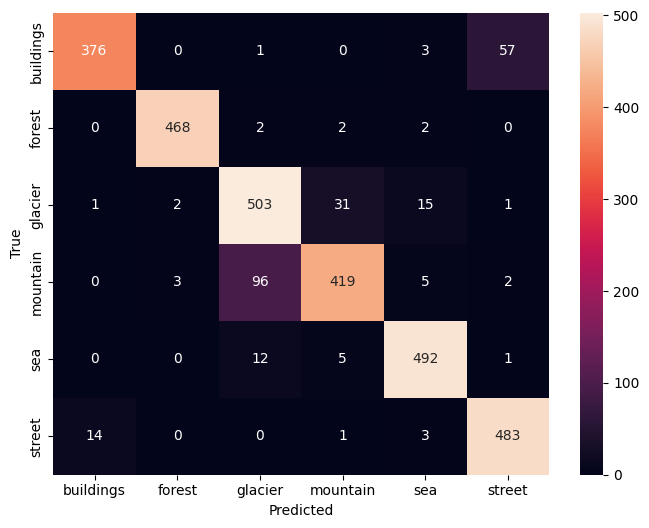

In [ ]:
# print confusion matrrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Re train model with fine tuning

In [ ]:
# unfreeze model
base_model.trainable = True

In [ ]:
# re freeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
# compile model with new, smaller learning rate to prevent overfitting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# train model
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 258ms/step - accuracy: 0.8647 - loss: 0.5520 - val_accuracy: 0.9062 - val_loss: 0.4057
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - accuracy: 0.9166 - loss: 0.2640 - val_accuracy: 0.9066 - val_loss: 0.3978
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 285ms/step - accuracy: 0.9353 - loss: 0.1860 - val_accuracy: 0.9048 - val_loss: 0.3830
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.9484 - loss: 0.1374 - val_accuracy: 0.9058 - val_loss: 0.3795
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.9562 - loss: 0.1190 - val_accuracy: 0.9069 - val_loss: 0.3738


In [ ]:
# evaulate with test
test_loss_ft, test_acc_ft = model.evaluate(test_generator)
print("Fine-tuned test accuracy:", test_acc_ft)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9123 - loss: 0.3318
Fine-tuned test accuracy: 0.9123333096504211


In [ ]:
# get predictions
y_pred_ft = model.predict(test_generator)
y_pred_classes_ft = np.argmax(y_pred_ft, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step


In [ ]:
# print  classification report
print(classification_report(y_true, y_pred_classes_ft, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.93      0.92      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.85      0.85      0.85       553
    mountain       0.85      0.84      0.85       525
         sea       0.93      0.96      0.94       510
      street       0.93      0.93      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



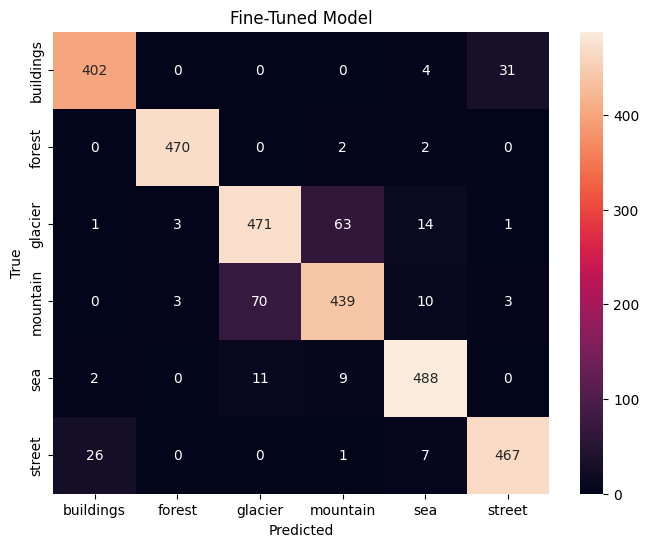

In [ ]:
# print confusion matrix
cm_ft = confusion_matrix(y_true, y_pred_classes_ft)

plt.figure(figsize=(8,6))
sns.heatmap(cm_ft, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Fine-Tuned Model")
plt.show()